## Modelo de regresión logística
Objetivo: Calcular probabilidad de adopción de las mascotas

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, roc_curve, mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [2]:
datos = pd.read_csv("aac_intakes_outcomes.csv")

In [3]:
datos.head()

,age_upon_outcome,animal_id_outcome,date_of_birth,outcome_subtype,outcome_type,sex_upon_outcome,age_upon_outcome_(days),age_upon_outcome_(years),age_upon_outcome_age_group,outcome_datetime,...,age_upon_intake_age_group,intake_datetime,intake_month,intake_year,intake_monthyear,intake_weekday,intake_hour,intake_number,time_in_shelter,time_in_shelter_days
0,10 years,A006100,2007-07-09 00:00:00,NaN,Return to Owner,Neutered Male,3650,10.0,"(7.5, 10.0]",2017-12-07 14:07:00,...,"(7.5, 10.0]",2017-12-07 00:00:00,12,2017,2017-12,Thursday,14,1.0,0 days 14:07:00.000000000,0.588194
1,7 years,A006100,2007-07-09 00:00:00,NaN,Return to Owner,Neutered Male,2555,7.0,"(5.0, 7.5]",2014-12-20 16:35:00,...,"(5.0, 7.5]",2014-12-19 10:21:00,12,2014,2014-12,Friday,10,2.0,1 days 06:14:00.000000000,1.259722
2,6 years,A006100,2007-07-09 00:00:00,NaN,Return to Owner,Neutered Male,2190,6.0,"(5.0, 7.5]",2014-03-08 17:10:00,...,"(5.0, 7.5]",2014-03-07 14:26:00,3,2014,2014-03,Friday,14,3.0,1 days 02:44:00.000000000,1.113889
3,10 years,A047759,2004-04-02 00:00:00,Partner,Transfer,Neutered Male,3650,10.0,"(7.5, 10.0]",2014-04-07 15:12:00,...,"(7.5, 10.0]",2014-04-02 15:55:00,4,2014,2014-04,Wednesday,15,1.0,4 days 23:17:00.000000000,4.970139
4,16 years,A134067,1997-10-16 00:00:00,NaN,Return to Owner,Neutered Male,5840,16.0,"(15.0, 17.5]",2013-11-16 11:54:00,...,"(15.0, 17.5]",2013-11-16 09:02:00,11,2013,2013-11,Saturday,9,1.0,0 days 02:52:00.000000000,0.119444


**Creamos nuevas variables**

Creamos la variable objetivo binaria "IsAdopted" y la variable reincidente para conocer si las mascotas que han estado más de una vez en el refugio tienen más o menos probabilidades de adopción.

In [4]:
datos['IsAdopted'] = (datos['outcome_type'] == 'Adoption').astype(int)
datos["Reentry"] = (datos["intake_number"] > 1).astype(int)

In [5]:
datos.head()

,age_upon_outcome,animal_id_outcome,date_of_birth,outcome_subtype,outcome_type,sex_upon_outcome,age_upon_outcome_(days),age_upon_outcome_(years),age_upon_outcome_age_group,outcome_datetime,...,intake_month,intake_year,intake_monthyear,intake_weekday,intake_hour,intake_number,time_in_shelter,time_in_shelter_days,IsAdopted,Reentry
0,10 years,A006100,2007-07-09 00:00:00,NaN,Return to Owner,Neutered Male,3650,10.0,"(7.5, 10.0]",2017-12-07 14:07:00,...,12,2017,2017-12,Thursday,14,1.0,0 days 14:07:00.000000000,0.588194,0,0
1,7 years,A006100,2007-07-09 00:00:00,NaN,Return to Owner,Neutered Male,2555,7.0,"(5.0, 7.5]",2014-12-20 16:35:00,...,12,2014,2014-12,Friday,10,2.0,1 days 06:14:00.000000000,1.259722,0,1
2,6 years,A006100,2007-07-09 00:00:00,NaN,Return to Owner,Neutered Male,2190,6.0,"(5.0, 7.5]",2014-03-08 17:10:00,...,3,2014,2014-03,Friday,14,3.0,1 days 02:44:00.000000000,1.113889,0,1
3,10 years,A047759,2004-04-02 00:00:00,Partner,Transfer,Neutered Male,3650,10.0,"(7.5, 10.0]",2014-04-07 15:12:00,...,4,2014,2014-04,Wednesday,15,1.0,4 days 23:17:00.000000000,4.970139,0,0
4,16 years,A134067,1997-10-16 00:00:00,NaN,Return to Owner,Neutered Male,5840,16.0,"(15.0, 17.5]",2013-11-16 11:54:00,...,11,2013,2013-11,Saturday,9,1.0,0 days 02:52:00.000000000,0.119444,0,0


**Eliminamos variables repetidas**

In [6]:
cols_to_drop = [
    "animal_id_outcome",
    "outcome_number"
]

datos = datos.drop(columns=cols_to_drop)

**Eliminamos posibles duplicados**

In [7]:
datos.drop_duplicates(inplace=True)

**Sustituimos valores NA**

In [8]:
datos['outcome_subtype'] = datos['outcome_subtype'].fillna('Unknown')

**Normalizamos texto**

In [9]:
cols_to_strip = ["animal_type", "breed", "sex_upon_outcome", "color", "found_location", "intake_condition", "intake_type", "sex_upon_intake", "outcome_type", "outcome_subtype", "outcome_weekday", "intake_weekday"]
for col in cols_to_strip:
    datos[col] = datos[col].str.strip().str.title()

**Seleccionamos las variables que vamos a utilizar en nuestro modelo**

In [10]:
features = ["sex_upon_intake", "age_upon_intake_age_group", "animal_type", "breed", "color", "intake_condition", "intake_type", "intake_month", "Reentry"]

**Definimos Y e X de nuestro modelo y creamos dummies de las variables categóricas**

Se elimina la primera categoría para evitar sobreajuste

In [11]:
X = datos[features]
y_class = datos["IsAdopted"]

X = pd.get_dummies(X, drop_first=True)


**Comporbamos que el dataset está balanceado**

In [12]:
distribution = pd.DataFrame({
    "Frecuencia": y_class.value_counts(),
    "Proporción": y_class.value_counts(normalize=True)
})

print(distribution)

           Frecuencia  Proporción
IsAdopted                        
0               46054    0.578299
1               33583    0.421701


**Dividimos los datos en datos de entrenamiento y datos test para evitar sobreajuste y evaluar su rendimiento en el futuro**

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

**Utilizamos Random Forest para seleccionar aquellas variables que discriminan mejor la variable objetivo**

In [14]:
rf_selector = RandomForestClassifier(
    n_estimators=200,
    n_jobs=-1,
    random_state=42
)

rf_selector.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [15]:
importances = pd.DataFrame({
    "Variable": X.columns,
    "Importance": rf_selector.feature_importances_
}).sort_values(by="Importance", ascending=False)

In [16]:
importances.head(15)

,Variable,Importance
0,intake_month,0.214668
5,sex_upon_intake_Unknown,0.040562
2707,intake_type_Owner Surrender,0.031576
2708,intake_type_Public Assist,0.023953
3,sex_upon_intake_Neutered Male,0.021283
2,sex_upon_intake_Intact Male,0.020474
1,Reentry,0.020331
10,"age_upon_intake_age_group_(2.5, 5.0]",0.019493
2709,intake_type_Stray,0.019386
4,sex_upon_intake_Spayed Female,0.018444


**Se van a seleccionar las 15 más importantes para el modelo de regresión logística**

In [17]:
selected_features = importances.head(15)["Variable"].tolist()
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

**Aplicamos validación cruzada**

In [18]:
log_model = LogisticRegression(max_iter=1000)

cv_scores = cross_val_score(log_model, X_train_sel, y_train, cv=5, scoring='roc_auc')

print("AUC medio CV:", cv_scores.mean())

AUC medio CV: 0.7180040027613657


**Entrenamos el modelo de regresión logística**

In [19]:
log_model.fit(X_train_sel, y_train)

LogisticRegression(max_iter=1000)

**Calculamos coeficientes de estimación**

In [20]:
coeficientes = pd.DataFrame({
    "Variable": selected_features,
    "Coeficiente": log_model.coef_[0]
}).sort_values(by="Coeficiente", key=abs, ascending=False)

coeficientes

,Variable,Coeficiente
1,sex_upon_intake_Unknown,-3.812156
2,intake_type_Owner Surrender,2.729392
8,intake_type_Stray,1.903083
10,intake_condition_Normal,0.818507
4,sex_upon_intake_Neutered Male,-0.706660
12,animal_type_Other,-0.602365
6,Reentry,0.572133
9,sex_upon_intake_Spayed Female,-0.508276
13,"age_upon_intake_age_group_(5.0, 7.5]",-0.501413
11,"age_upon_intake_age_group_(7.5, 10.0]",-0.487804


Una vez realizado el modelo, predecimos en los datos de test si es adoptado o no y las probabilidades de que sea uno o el otro

In [21]:
y_pred = log_model.predict(X_test_sel)
y_prob = log_model.predict_proba(X_test_sel)[:,1]

**Calculamos métricas de evaluación de modelo**

In [22]:
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("AUC:", auc)
print(classification_report(y_test, y_pred))

Accuracy: 0.6521848317428428
AUC: 0.7193132302748166
              precision    recall  f1-score   support

           0       0.74      0.62      0.67      9211
           1       0.57      0.70      0.63      6717

    accuracy                           0.65     15928
   macro avg       0.65      0.66      0.65     15928
weighted avg       0.67      0.65      0.65     15928



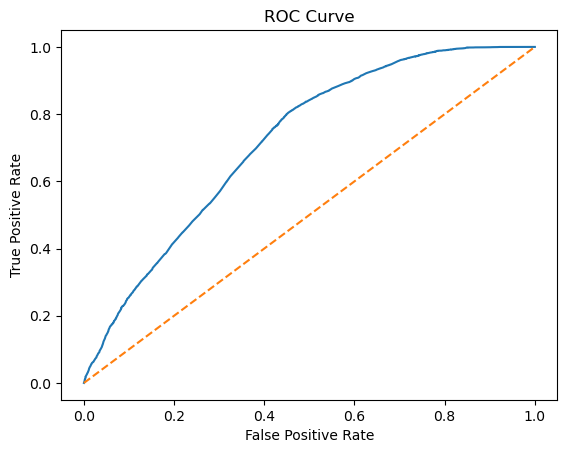

In [23]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

## Modelo de regresión 
Objetivo: Predecir el tiempo de estancia en el refugio

**Definir variable objetivo y variables explicativas**

In [24]:
y_reg = datos["time_in_shelter_days"]
X_reg = X.copy()

<Axes: >

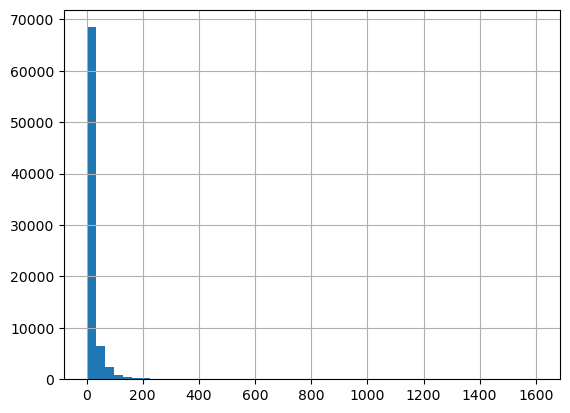

In [25]:
y_reg.describe()
y_reg.hist(bins=50)

**Winsorización**

In [26]:
q95 = y_reg.quantile(0.95)
y_reg = y_reg.clip(upper=q95)


**División del modelo en conjunto de entrenamiento y de prueba**

In [27]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)


**Creación del modelo de regresión**

In [28]:
rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train_reg, y_train_reg)

RandomForestRegressor(max_features='sqrt', min_samples_leaf=5,
                      min_samples_split=10, n_estimators=400, n_jobs=-1,
                      random_state=42)

**Variables de evaluación de modelo**

In [29]:
y_pred = rf.predict(X_test_reg)

mae = mean_absolute_error(y_test_reg, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
r2 = r2_score(y_test_reg, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 12.968959368303596
RMSE: 18.35764485053178
R2: 0.08559014500386875


**Importancias relativas**

In [30]:
importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top15 = importances.head(15)
print(top15)

sex_upon_intake_Unknown          0.108776
animal_type_Cat                  0.084405
breed_Pit Bull Mix               0.066951
breed_Domestic Shorthair Mix     0.060134
intake_type_Wildlife             0.053268
animal_type_Dog                  0.048480
animal_type_Other                0.040868
intake_month                     0.031767
intake_type_Owner Surrender      0.030910
intake_condition_Nursing         0.018786
sex_upon_intake_Intact Male      0.017788
breed_Bat Mix                    0.017735
intake_type_Stray                0.014441
breed_Chihuahua Shorthair Mix    0.013308
color_Brown                      0.013290
dtype: float64
